# Анализ международного SaaS-продукта: рост, отток и удержание пользователей

In [1]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

## Рост числа пользователей

In [2]:
growth=pd.read_csv('../data/processed/mom_growth.csv')
growth['month_short']=growth['month'].str[:7]

growth.head()

,month,new_customers,running_total_new_customers,mom_growth_percentage,month_short
0,2023-01-01,2,2,NaN,2023-01
1,2023-02-01,8,10,300.00,2023-02
2,2023-03-01,11,21,37.50,2023-03
3,2023-04-01,15,36,36.36,2023-04
4,2023-05-01,14,50,-6.67,2023-05


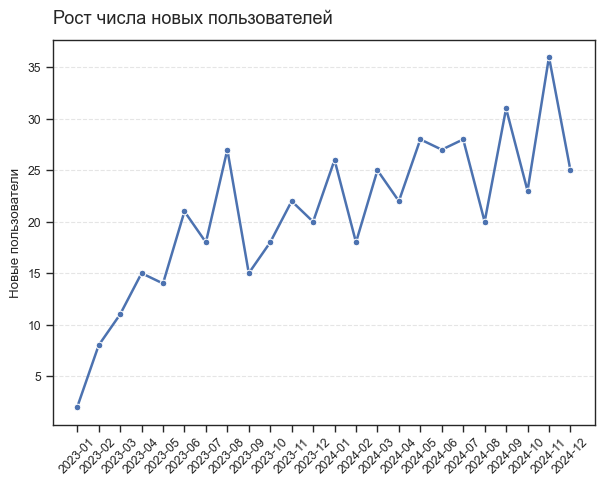

In [3]:
# Новые пользователи

sns.set_theme(style='ticks', context='paper', palette='deep')

plt.figure(figsize=(7, 5))
ax=sns.lineplot(data=growth, x='month_short', y='new_customers', marker='o', linewidth=1.8)
ax.tick_params(axis='x', rotation=45)
ax.set_xlabel('')
ax.set_ylabel('Новые пользователи')
ax.set_title('Рост числа новых пользователей', loc='left', y=1.02, fontsize=13)
ax.grid(axis='y', alpha=0.5, linestyle='--')

plt.savefig('../visuals/new_customers_per_month.png', dpi=150, bbox_inches='tight')
plt.show()

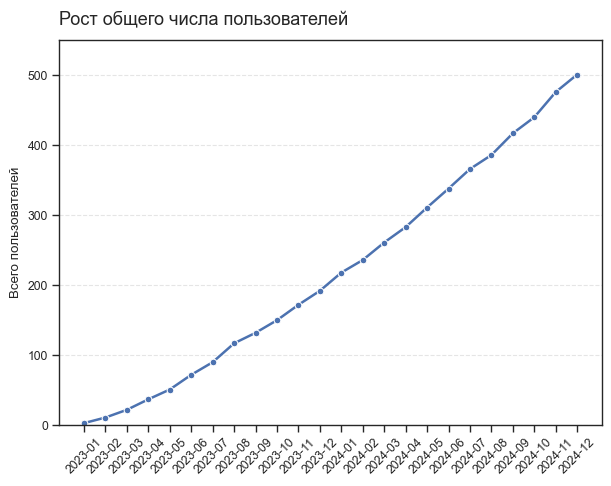

In [4]:
# Рост общего числа пользователей

plt.figure(figsize=(7, 5))
ax=sns.lineplot(data=growth, x='month_short', y='running_total_new_customers', marker='o', linewidth=1.8)
ax.tick_params(axis='x', rotation=45)
ax.set_ylim(0, 550)
ax.set_xlabel('')
ax.set_ylabel('Всего пользователей')
ax.set_title("Рост общего числа пользователей", loc='left', y=1.02, fontsize=13)
ax.grid(axis='y', alpha=0.5, linestyle='--')

plt.savefig('../visuals/new_customers_running_total.png', dpi=150, bbox_inches='tight')
plt.show()

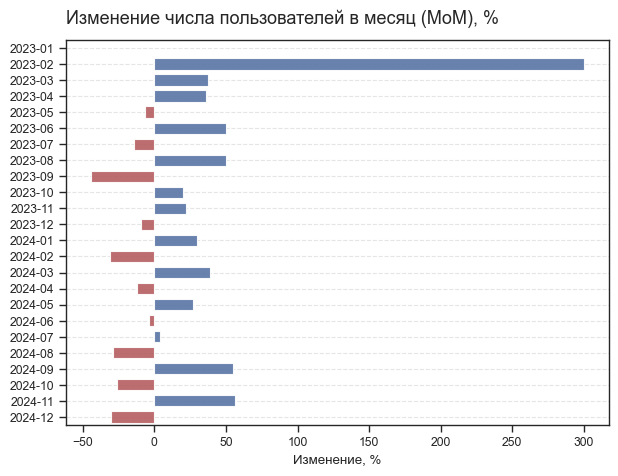

In [5]:
# Процентное изменение числа пользователей в месяц (MoM)

growth['trend']=growth['mom_growth_percentage'].apply(
    lambda x: 'negative' if x<0 else 'positive')

fig,ax=plt.subplots(figsize=(7, 5))
ax=sns.barplot(data=growth, 
               y='month_short', 
               x='mom_growth_percentage', 
               hue='trend', 
               palette={'positive':'#4c72b0','negative':'#c44e52'}, 
               alpha=0.9, 
               width=0.7)
ax.set_xlabel('Изменение, %')
ax.set_ylabel('')
ax.set_title('Изменение числа пользователей в месяц (MoM), %', loc='left', y=1.02, fontsize=13)
ax.legend_.remove()
ax.grid(axis='y', alpha=0.5, linestyle='--')

plt.savefig('../visuals/mom_growth_percentage.png', dpi=150, bbox_inches='tight')
plt.show()

Рост числа новых пользователей неравномерный с заметными пиками и спадами, без выраженной сезонности. Процентное изменение числа новых пользователей в месяц MoM за весь период находится в диапазоне от -44% до 300%. Общая пользовательская база растет (линейная положительная динамика) – число пользователей за два года увеличилось до 500.
## Отток пользователей по сегментам

In [6]:
churn=pd.read_csv('../data/processed/churn_segments.csv')
churn.head()

,segment,subsegment,total_accounts,churned_accounts,churned_share_percentage
0,country,UK,58,45,77.59
1,country,FR,22,16,72.73
2,country,US,291,206,70.79
3,country,CA,23,16,69.57
4,country,AU,32,22,68.75


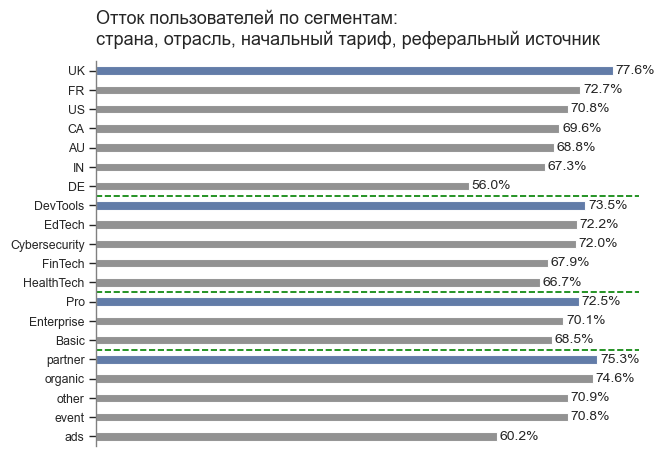

In [7]:
colors=[]
for s in churn['subsegment']:
    if s in ['UK', 'DevTools', 'Pro', 'partner']:
        colors.append('#4c72b0')
    else:
        colors.append('#8c8c8c')

plt.figure(figsize=(7, 5))

ax=sns.barplot(data=churn,
               y='subsegment',
               x='churned_share_percentage',
               hue='subsegment',
              alpha=0.95,
              palette=colors, 
               width=0.43)

ax.set_title('Отток пользователей по сегментам:\nстрана, отрасль, начальный тариф, реферальный источник', 
             loc='left', y=1.02, fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks([])
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.spines['left'].set_color('grey')

ax.grid(False)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=2, fontsize=10)

countries_count=len(churn[churn['segment']=='country'])
industry_count=len(churn[churn['segment']=='industry'])
plan_count=len(churn[churn['segment']=='initial_plan_tier'])

y1=countries_count - 0.5
y2=countries_count + industry_count - 0.5
y3=countries_count + industry_count + plan_count - 0.5

ax.axhline(y=y1, color='green', linestyle='--')
ax.axhline(y=y2, color='green', linestyle='--')
ax.axhline(y=y3, color='green', linestyle='--')

plt.savefig('../visuals/churn_per_segment.png', dpi=150, bbox_inches='tight')
plt.show()

Самые высокие показатели оттока по сегментам: страна – Великобритания, отрасль – разработка ПО, начальный тариф – Pro, реферальный источник – партнеры. 
## Удержание пользователей по когортам (по продуктовой активности и оплате)

In [8]:
# Когортный анализ удержания пользователей (по продуктовой активности)

retention_a=pd.read_csv('../data/processed/retention_activity_based.csv')
retention_a['cohort_m_short']=retention_a['cohort_month'].str[:7]

retention_a.head()

,cohort_month,month_number,active_accounts,cohort_size,product_retention_rate_percentage,cohort_m_short
0,2023-01-01,0,16,17,94.12,2023-01
1,2023-01-01,1,11,17,64.71,2023-01
2,2023-01-01,2,11,17,64.71,2023-01
3,2023-01-01,3,11,17,64.71,2023-01
4,2023-01-01,4,10,17,58.82,2023-01


In [9]:
retention_a_pivot=retention_a.pivot(index='cohort_m_short', 
                                      columns='month_number', 
                                      values='product_retention_rate_percentage')
retention_a_pivot.head()

month_number,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
cohort_m_short,,,,,,,,,,,,,,,,,,,,,
2023-01,94.12,64.71,64.71,64.71,58.82,47.06,47.06,47.06,35.29,29.41,...,23.53,23.53,17.65,17.65,11.76,11.76,11.76,11.76,11.76,11.76
2023-02,94.44,83.33,77.78,61.11,50.00,44.44,38.89,33.33,33.33,33.33,...,16.67,11.11,11.11,11.11,11.11,11.11,5.56,5.56,5.56,NaN
2023-03,85.00,80.00,70.00,60.00,55.00,45.00,40.00,30.00,30.00,25.00,...,10.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,NaN,NaN
2023-04,86.67,73.33,66.67,60.00,60.00,53.33,46.67,40.00,40.00,40.00,...,20.00,20.00,20.00,13.33,13.33,13.33,13.33,NaN,NaN,NaN
2023-05,92.31,76.92,73.08,61.54,57.69,57.69,46.15,42.31,42.31,42.31,...,19.23,11.54,11.54,11.54,7.69,7.69,NaN,NaN,NaN,NaN


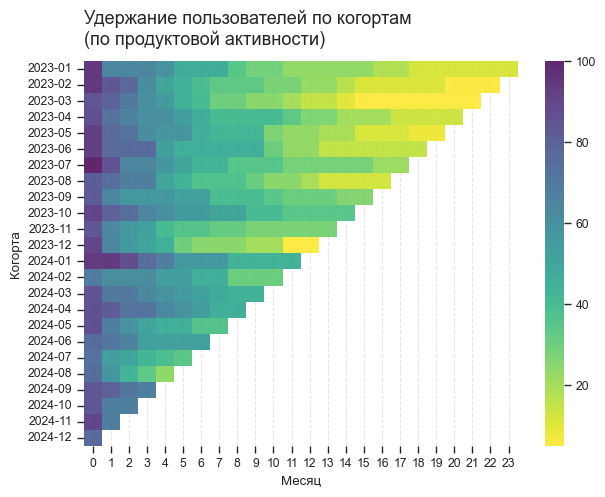

In [10]:
plt.figure(figsize=(7,5))
ax=sns.heatmap(data=retention_a_pivot, cmap='viridis_r', alpha=0.85)
ax.set_title('Удержание пользователей по когортам\n(по продуктовой активности)', 
             loc='left', 
             y=1.02,
            fontsize=13)
ax.set_xlabel('Месяц')
ax.set_ylabel('Когорта')
ax.grid(axis='x', alpha=0.5, linestyle='--')

plt.savefig('../visuals/retention_usage.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Когортный анализ удержания пользователей (по оплате, до первого оттока (churn))

retention_p=pd.read_csv('../data/processed/retention_first_churn_based.csv')
retention_p['cohort_m_short']=retention_p['cohort_month'].str[:7]

retention_p.head()

,cohort_month,month_number,active_accounts,cohort_size,payment_retention_rate_till_first_churn_percentage,cohort_m_short
0,2023-01-01,0,17,17,100.00,2023-01
1,2023-01-01,1,16,17,94.12,2023-01
2,2023-01-01,2,16,17,94.12,2023-01
3,2023-01-01,3,16,17,94.12,2023-01
4,2023-01-01,4,15,17,88.24,2023-01


In [12]:
retention_p_pivot=retention_p.pivot(index='cohort_m_short', 
                                      columns='month_number', 
                                      values='payment_retention_rate_till_first_churn_percentage')
retention_p_pivot.head()

month_number,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
cohort_m_short,,,,,,,,,,,,,,,,,,,,,
2023-01,100.0,94.12,94.12,94.12,88.24,76.47,76.47,70.59,70.59,64.71,...,41.18,41.18,41.18,41.18,35.29,29.41,29.41,29.41,29.41,29.41
2023-02,100.0,100.00,88.89,83.33,83.33,77.78,77.78,77.78,77.78,72.22,...,50.00,50.00,50.00,50.00,50.00,50.00,50.00,33.33,33.33,NaN
2023-03,100.0,85.00,85.00,85.00,70.00,65.00,50.00,45.00,35.00,35.00,...,20.00,20.00,20.00,20.00,20.00,20.00,20.00,20.00,NaN,NaN
2023-04,100.0,93.33,93.33,86.67,80.00,80.00,80.00,80.00,80.00,80.00,...,73.33,60.00,46.67,40.00,40.00,40.00,40.00,NaN,NaN,NaN
2023-05,100.0,100.00,100.00,100.00,88.46,88.46,84.62,76.92,76.92,73.08,...,65.38,65.38,61.54,57.69,53.85,53.85,NaN,NaN,NaN,NaN


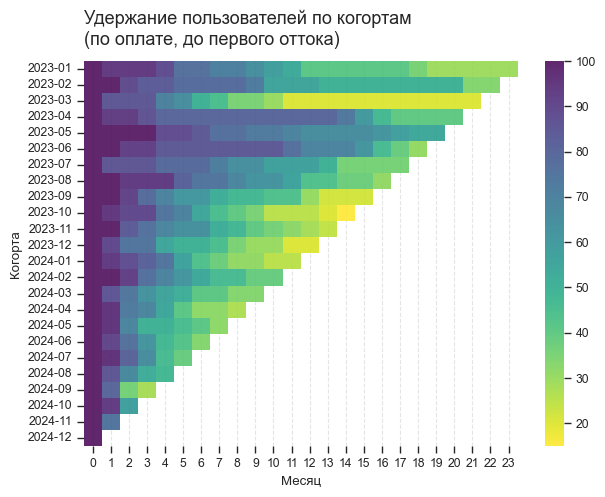

In [13]:
plt.figure(figsize=(7,5))
ax=sns.heatmap(data=retention_p_pivot, cmap='viridis_r', alpha=0.85)
ax.set_title('Удержание пользователей по когортам\n(по оплате, до первого оттока)', 
             loc='left', 
             y=1.02,
            fontsize=13)
ax.set_xlabel('Месяц')
ax.set_ylabel('Когорта')
ax.grid(axis='x', alpha=0.5, linestyle='--')

plt.savefig('../visuals/retention_payment_first_churn.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Когортный анализ удержания пользователей (по оплате, до последнего оттока (churn))

retention_p2=pd.read_csv('../data/processed/retention_last_churn_based.csv')
retention_p2['cohort_m_short']=retention_p2['cohort_month'].str[:7]

retention_p2.head()

,cohort_month,month_number,active_accounts,cohort_size,payment_retention_rate_till_last_churn_percentage,cohort_m_short
0,2023-01-01,0,17,17,100.0,2023-01
1,2023-01-01,1,17,17,100.0,2023-01
2,2023-01-01,2,17,17,100.0,2023-01
3,2023-01-01,3,17,17,100.0,2023-01
4,2023-01-01,4,17,17,100.0,2023-01


In [15]:
retention_p2_pivot=retention_p2.pivot(index='cohort_m_short', 
                                      columns='month_number', 
                                      values='payment_retention_rate_till_last_churn_percentage')
retention_p2_pivot.head()

month_number,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
cohort_m_short,,,,,,,,,,,,,,,,,,,,,
2023-01,100.0,100.0,100.00,100.00,100.00,88.24,88.24,82.35,82.35,82.35,...,64.71,64.71,64.71,58.82,52.94,41.18,35.29,35.29,29.41,29.41
2023-02,100.0,100.0,94.44,88.89,88.89,88.89,88.89,88.89,88.89,88.89,...,77.78,61.11,61.11,55.56,55.56,50.00,50.00,33.33,33.33,NaN
2023-03,100.0,95.0,95.00,90.00,80.00,75.00,75.00,75.00,70.00,70.00,...,45.00,45.00,45.00,45.00,40.00,35.00,35.00,30.00,NaN,NaN
2023-04,100.0,100.0,100.00,100.00,93.33,93.33,93.33,93.33,93.33,93.33,...,86.67,66.67,53.33,46.67,46.67,46.67,40.00,NaN,NaN,NaN
2023-05,100.0,100.0,100.00,100.00,96.15,96.15,96.15,92.31,92.31,92.31,...,84.62,84.62,84.62,76.92,65.38,57.69,NaN,NaN,NaN,NaN


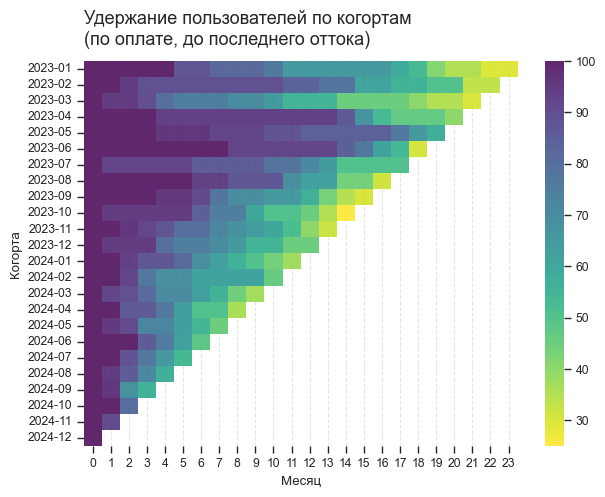

In [16]:
plt.figure(figsize=(7,5))
ax=sns.heatmap(data=retention_p2_pivot, cmap='viridis_r', alpha=0.85)
ax.set_title('Удержание пользователей по когортам\n(по оплате, до последнего оттока)', 
             loc='left', 
             y=1.02, 
            fontsize=13)
ax.set_xlabel('Месяц')
ax.set_ylabel('Когорта')
ax.grid(axis='x', alpha=0.5, linestyle='--')

plt.savefig('../visuals/retention_payment_last_churn.png', dpi=150, bbox_inches='tight')
plt.show()

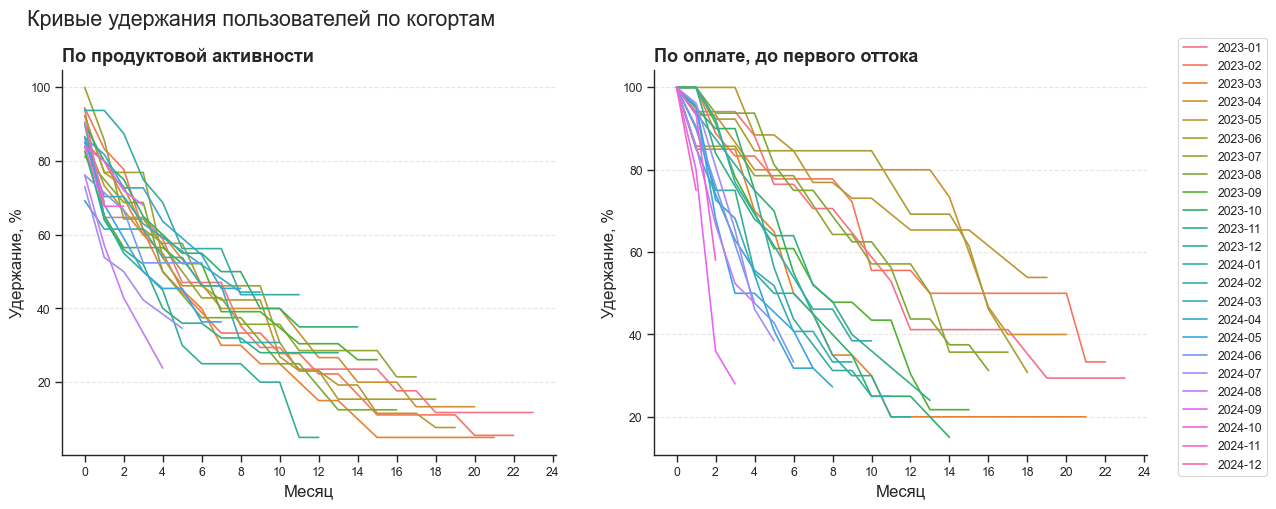

In [17]:
# Кривые удержания по когортам (по продуктовой активности и оплате (до первого оттока))

fig, (ax1, ax2)=plt.subplots(1,2, figsize=(14,5))
sns.lineplot(data=retention_a, 
                x='month_number', 
                y='product_retention_rate_percentage',
                hue='cohort_m_short',
                ax=ax1)
ax1.set_title('По продуктовой активности', 
             loc='left',
            fontsize=13,
             fontweight='bold')
ax1.set_xlabel ('Месяц', fontsize=12)
ax1.set_ylabel ('Удержание, %', fontsize=12)
ax1.set_xticks(range(0, 25, 2))
ax1.grid(axis='y', alpha=0.5, linestyle='--')
ax1.legend_.remove()
ax1.spines[['top', 'right']].set_visible(False)

sns.lineplot(data=retention_p, 
                x='month_number', 
                y='payment_retention_rate_till_first_churn_percentage',
                hue='cohort_m_short',
                ax=ax2)
ax2.set_title('По оплате, до первого оттока', 
             loc='left',
            fontsize=13,
             fontweight='bold')
ax2.set_xlabel ('Месяц', fontsize=12)
ax2.set_ylabel ('Удержание, %', fontsize=12)
ax2.set_xticks(range(0, 25, 2))
ax2.grid(axis='y', alpha=0.5, linestyle='--')
ax2.legend(title=None, bbox_to_anchor=(1.05, 1.1))
ax2.spines[['top', 'right']].set_visible(False)

plt.suptitle('Кривые удержания пользователей по когортам', ha='left', x=0.1, y=1.001, fontsize=15.5)

plt.savefig('../visuals/retention_curves_usage_payment.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Среднее удержание пользователей в первый месяц и через год 
# по продуктовой активности, по оплате (до первого оттока), по оплате (до последнего оттока)

print(retention_a_pivot[0].mean(), retention_a_pivot[12].mean())
print(retention_p_pivot[0].mean(), retention_p_pivot[12].mean())
print(retention_p2_pivot[0].mean(), retention_p2_pivot[12].mean())

85.58458333333333 23.277500000000003
100.0 44.639166666666675
100.0 66.14583333333333


Среднее удержание по продуктовой активности в первый месяц (месяц 0) составляет 86%, через год (месяц 12) показатель снижается до 23%. При этом удержание во второй месяц (месяц 1) может снижаться сразу на 30%.  
Среднее удержание по оплате до первого оттока выше, чем по продуктовой активности: в первый месяц (месяц 0) оно составляет 100%, а через год (месяц 12) снижается до 45%. Это значит, что пользователи могут продолжать платить, но не использовать продукт.  
Часть пользователей возвращается после первого оттока: среднее удержание по оплате до последнего оттока в первый месяц (месяц 0) составляет 100%, через год (месяц 12) снижаясь до 66%.
## Воронка активации

In [19]:
median_activation_time=retention_ab=pd.read_csv('../data/processed/median_activation_time_days.csv')
median_activation_time.head()

,median_subscription_from_signup_time_days,median_usage_from_signup_time_days
0,16.0,5.0


In [20]:
usage_data_agg=median_activation_time=retention_ab=pd.read_csv('../data/processed/usage_data_agg.csv')
usage_data_agg

,total_count,valid_usage_data,invalid_usage_data
0,500,10,490


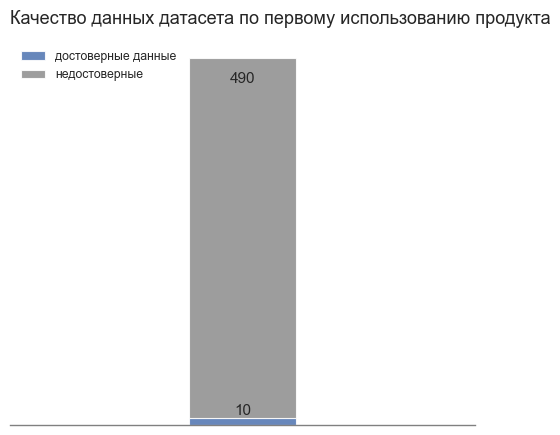

In [21]:
df = usage_data_agg[['valid_usage_data', 'invalid_usage_data']]

fig,ax=plt.subplots(figsize=(6,5))

df.plot.bar(stacked=True, width=0.15, ax=ax, color=['#4c72b0', '#8c8c8c'], alpha=0.85)
ax.bar_label(ax.containers[0], labels=df.valid_usage_data, fontsize=11)
ax.bar_label(ax.containers[1], labels=df.invalid_usage_data, padding=-20, fontsize=11)
ax.set_title('Качество данных датасета по первому использованию продукта', loc='left', y=1.02, fontsize=13)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xticklabels('')
ax.legend(title=None, labels=['достоверные данные', 'недостоверные'], loc='upper left', frameon=False)
ax.spines[['top', 'left', 'right']].set_visible(False)
ax.spines['bottom'].set_color('grey')
ax.grid(alpha=0.2)

plt.show()

Из-за проблем с качеством данных (почти все даты первого использования продукта предшествуют датам регистрации аккаунта, а также нет аккаунтов без подписок или использования продукта) результаты анализа активации оказались неинформативными: в частности, конверсия равна 100%.  
Анализ был ограничен расчетом медианы времени, которое проходит с момента регистрации аккаунта до первой подписки – 16 дней, и медианы времени, которое проходит с момента регистрации аккаунта до первого использования – 5 дней. 
## Активные пользователи в месяц (MAU)

In [22]:
mau=pd.read_csv('../data/processed/monthly_active_users.csv')
mau['active_month_short']=mau['active_month'].str[:7]
mau.head()

,active_month,mau,active_month_short
0,2023-01-01,8,2023-01
1,2023-02-01,23,2023-02
2,2023-03-01,42,2023-03
3,2023-04-01,59,2023-04
4,2023-05-01,74,2023-05


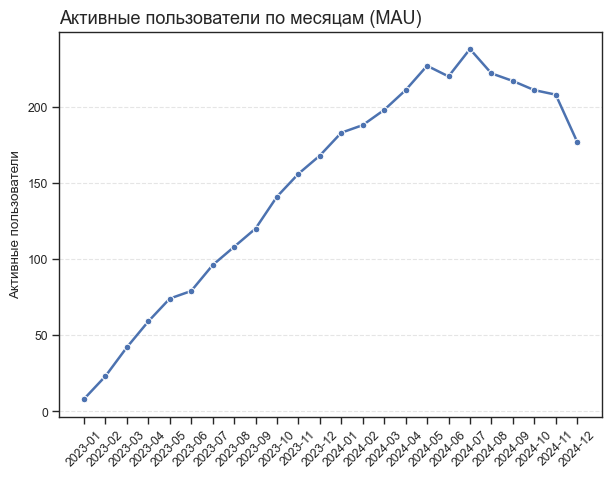

In [23]:
plt.figure (figsize=(7,5))
ax=sns.lineplot(data=mau,
                x='active_month_short',
                y='mau',
                marker='o',
                linewidth=1.8)
ax.set_xlabel('')
ax.set_ylabel('Активные пользователи')
ax.set_title('Активные пользователи по месяцам (MAU)', loc='left', fontsize=13)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.savefig('../visuals/monthly_active_users.png', dpi=150, bbox_inches='tight')
plt.show()

Число активных пользователей в месяц MAU устойчиво растет начиная с запуска продукта и до июля 2024 г., после чего переходит к снижению. MAU в среднем составляет 149 пользователей в месяц. Однако этот показатель также частично ненадежен из-за проблем с качеством данных. 
## Продуктовая активность и отток пользователей

In [24]:
usage_segments=pd.read_csv('../data/processed/usage_segments.csv')
usage_segments

,usage_segment,accounts,segment_share_percentage,churned_accounts,churn_rate_percentage,avg_lifetime_months
0,low usage,272,54.4,191,70.22,8.36
1,medium usage,219,43.8,154,70.32,2.96
2,high usage,9,1.8,7,77.78,2.22


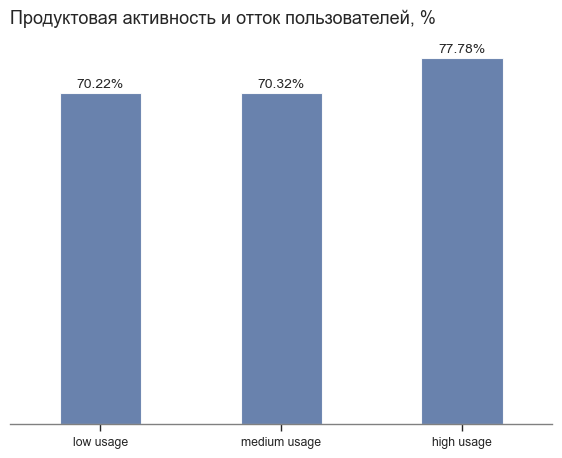

In [25]:
plt.figure(figsize=(7,5))
ax=sns.barplot(data=usage_segments, 
               x='usage_segment', 
               y='churn_rate_percentage', 
               width=0.45, 
              alpha=0.9)
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('Продуктовая активность и отток пользователей, %', loc='left', fontsize=13, y=1.02)
ax.bar_label(ax.containers[0], fmt='%.2f%%', padding=2, fontsize=10)
ax.spines[['top', 'left', 'right']].set_visible(False)
ax.spines['bottom'].set_color('grey')
ax.grid(False)

plt.savefig('../visuals/usage_churn_linkage.png', dpi=150, bbox_inches='tight')
plt.show()

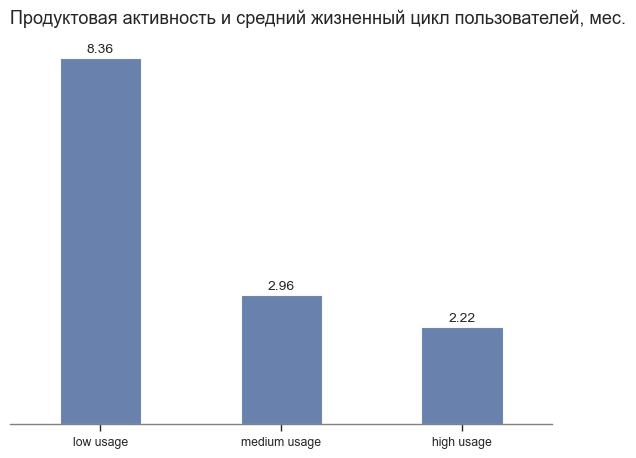

In [26]:
plt.figure(figsize=(7,5))
ax=sns.barplot(data=usage_segments, 
               x='usage_segment', 
               y='avg_lifetime_months', 
               width=0.45,
              alpha=0.9)
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')
ax.bar_label(ax.containers[0], padding=2, fontsize=10)
ax.set_title('Продуктовая активность и средний жизненный цикл пользователей, мес.', 
             loc='left', y=1.02, fontsize=13)
ax.grid(False)
ax.spines[['top', 'left', 'right']].set_visible(False)
ax.spines['bottom'].set_color('grey')

plt.savefig('../visuals/usage_lifetime_linkage.png', dpi=150, bbox_inches='tight')
plt.show()

Сегментация пользователей по продуктовой активности и расчет оттока по сегментам показали отсутствие явной зависимости между уровнем продуктовой активности и удержанием пользователей в рамках данного датасета. Уровень оттока пользователей с высокой продуктовой активностью составляет 77,78%, с низкой продуктовой активностью – 70,22%. Также было выявлено, что для пользователей с высокой продуктовой активностью характерен более короткий жизненный цикл (2,22 месяца) по сравнению с пользователями с низкой продуктовой активностью (8,36 месяцев). 
## Метрики продукта по странам

In [27]:
accounts_summary=usage_segments=pd.read_csv('../data/processed/accounts_summary.csv')
accounts_summary.head()

,account_id,industry,country,signup_date,referral_source,initial_plan_tier,seats,subscriptions,approx_revenue_till_churn,lifetime_months_till_churn,...,used_beta_feature,support_tickets,avg_resolution_time,avg_satisfaction_score,escalations,churn_flag,first_churn_date,reason_code,first_refund_usd,total_refund_usd
0,A-f92792,FinTech,US,2024-07-04,ads,Pro,1,14,27402,3,...,1,2,45.00,4.00,0,1,2024-11-03,features,0.0,0.0
1,A-417d2f,Cybersecurity,IN,2023-07-04,partner,Pro,4,16,224781,17,...,1,6,43.50,4.33,0,1,2024-12-30,budget,0.0,0.0
2,A-10b8da,DevTools,US,2023-05-08,partner,Enterprise,14,6,55582,19,...,1,3,31.33,3.50,0,0,NaN,NaN,0.0,0.0
3,A-bc4d48,EdTech,US,2024-06-12,ads,Pro,35,7,29715,6,...,1,6,41.17,4.20,1,0,NaN,NaN,0.0,0.0
4,A-69b156,EdTech,US,2023-11-21,other,Pro,7,9,105295,13,...,1,7,32.00,4.00,0,0,NaN,NaN,0.0,0.0


In [28]:
countries=accounts_summary.groupby('country')['account_id'].count().sort_values().reset_index()
countries

,country,account_id
0,FR,22
1,CA,23
2,DE,25
3,AU,32
4,IN,49
5,UK,58
6,US,291


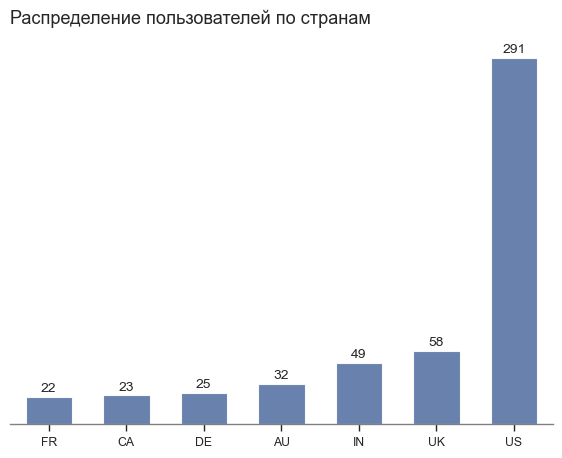

In [29]:
plt.figure(figsize=(7,5))
ax=sns.barplot(data=countries, 
               x='country', 
               y='account_id', 
               width=0.6,
              alpha=0.9)
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')
ax.bar_label(ax.containers[0], padding=2, fontsize=10)
ax.set_title('Распределение пользователей по странам', loc='left', y=1.02, fontsize=13)
ax.grid(False)
ax.spines[['top', 'left', 'right']].set_visible(False)
ax.spines['bottom'].set_color('grey')

plt.savefig('../visuals/countries_customers.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
countries_churn=accounts_summary.groupby('country')['churn_flag'].sum().sort_values().reset_index()
countries_churn

,country,churn_flag
0,DE,14
1,CA,16
2,FR,16
3,AU,22
4,IN,33
5,UK,45
6,US,206


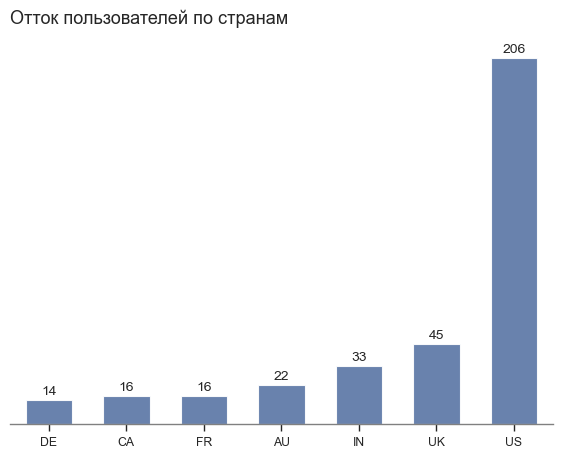

In [31]:
plt.figure(figsize=(7,5))
ax=sns.barplot(data=countries_churn, 
               x='country', 
               y='churn_flag', 
               width=0.6,
              alpha=0.9)
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')
ax.bar_label(ax.containers[0], padding=2, fontsize=10)
ax.set_title('Отток пользователей по странам', loc='left', y=1.02, fontsize=13)
ax.grid(False)
ax.spines[['top', 'left', 'right']].set_visible(False)
ax.spines['bottom'].set_color('grey')

plt.savefig('../visuals/countries_churn.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
countries_lt=accounts_summary.groupby('country')['lifetime_months_till_churn'].mean().sort_values().reset_index()
countries_lt

,country,lifetime_months_till_churn
0,FR,5.409091
1,UK,5.413793
2,CA,5.565217
3,US,5.639175
4,AU,5.656250
5,IN,6.857143
6,DE,8.920000


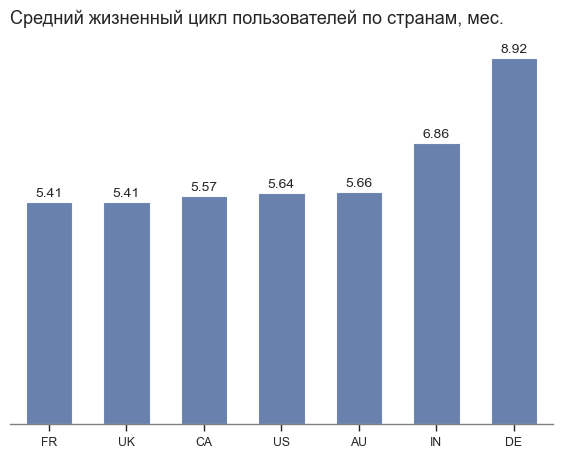

In [33]:
plt.figure(figsize=(7,5))
ax=sns.barplot(data=countries_lt, 
               x='country', 
               y='lifetime_months_till_churn', 
               width=0.6,
              alpha=0.9)
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')
ax.bar_label(ax.containers[0], fmt='%.2f', padding=2, fontsize=10)
ax.set_title('Средний жизненный цикл пользователей по странам, мес.', loc='left', y=1.02, fontsize=13)
ax.grid(False)
ax.spines[['top', 'left', 'right']].set_visible(False)
ax.spines['bottom'].set_color('grey')

plt.savefig('../visuals/countries_lifetime.png', dpi=150, bbox_inches='tight')
plt.show()

Распределение пользователей по странам неравномерное: продукт представлен в 7 странах, 58% пользователей находится в США, на втором месте по числу пользователей – Великобритания (12%). Показатели общего абсолютного оттока пользователей также выше в США и Великобритании – 206 и 45 пользователей соответственно. Лидеры по среднему жизненному циклу пользователей – Германия (8,92 месяца) и Индия (6,86 месяцев).